# **Modell**

### **Libraries**

In [7]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline



In [8]:
%store -r x_train
x_train= x_train

%store -r y_train
y_train= y_train

%store -r x_test
x_test= x_test

%store -r y_test
y_test= y_test



%store -r preprocessor
preprocessor=preprocessor



##### *code Explain*

- KFold(n_splits=5) → 5-fache Cross-Validation

- shuffle=True → mischt die Daten, damit die Folds zufällig sind

- random_state=42 → sorgt für Reproduzierbarkeit

In [9]:
from sklearn.metrics import mean_absolute_error


def evaluate_models(x_train, y_train, x_val, y_val, model):
    # Cross-validation
    kf=KFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate cross-validated R^2 and RMSE
    cross_val_r2= cross_val_score(
        model,
        x_train, 
        y_train, 
        cv=kf, 
        scoring='r2',
        error='raise')

    # Note: 'neg_root_mean_squared_error' returns negative values, so we take the negative to get RMSE
    cross_val_rmse= -cross_val_score(model, x_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

    print(f"Training CV R^2:{cross_val_r2.mean():.4f}, Training CR RMSE: {cross_val_rmse.mean():.4f}")

    # Train the model
    model.fit(x_train, y_train)
    print("Model trained successfully.")
    print(x_train.shape, y_train.shape)
    print(x_val.shape, y_val.shape)
    
    # Make predictions
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)
    print("Model prediction successfully.")
 

    r2_train= r2_score(y_train, y_train_pred)
    rmse_train= np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    r2= r2_score(y_val, y_val_pred)
    rmse= np.sqrt(mean_squared_error(y_val, y_val_pred))

    # 
     # MAE
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)

    # Prozentuale Abweichung
    prozent_train = (mae_train / np.mean(y_train)) * 100
    prozent_val = (mae_val / np.mean(y_val)) * 100

    print(f" Validation MAE: {mae_val:.2f}, Validation Fehler %: {prozent_val:.2f}%")
    #print(f"Validation R^2: {r2_val:.4f}, Validation RMSE: {rmse_val:.2f}, Validation MAE: {mae_val:.2f}, Validation Fehler %: {prozent_val:.2f}%")
   # print(f"Train R^2: {r2_train:.4f}, Train RMSE: {rmse_train:.2f}, Train MAE: {mae_train:.2f}, Train Fehler %: {prozent_train:.2f}%")

    
    print(f"Train R^2: {r2_train:.4f}, Train RMSE: {rmse_train:.4f}")
    print(f"Validation R^2: {r2:.4f}, Validation RMSE: {rmse:.4f}")

In [10]:
def evaluate_model(X_train, y_train, X_val, y_val, model):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    r2_cv = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='r2',
         error_score='raise'
    )

    rmse_cv = -cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='neg_root_mean_squared_error'
    )
    
    print(f"CV R²: {r2_cv.mean():.4f}")
    print(f"CV RMSE: {rmse_cv.mean():.4f}")

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    r2_val = r2_score(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

    mae_val = mean_absolute_error(y_val, y_val_pred)
    percent_error = (mae_val / np.mean(y_val)) * 100

    print("\nFinal Model Performance")
    print(f"Train R²: {r2_train:.4f} | Train RMSE: {rmse_train:.2f}")
    print(f"Val   R²: {r2_val:.4f} | Val   RMSE: {rmse_val:.2f}")
    print(f"Val MAE: {mae_val:.2f}")
    print(f"Mean Error %: {percent_error:.2f}%") 


#### **Model Training**

##### **Linear Regression**

In [11]:
model_LR=Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', LinearRegression())
])

In [12]:
evaluate_model(x_train, y_train, x_test, y_test, model_LR)

CV R²: nan
CV RMSE: 572.9456

Final Model Performance
Train R²: 1.0000 | Train RMSE: 0.00
Val   R²: -2.1863 | Val   RMSE: 892.51
Val MAE: 709.37
Mean Error %: 10.59%


In [13]:
model_Linear = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regression", LinearRegression())
])
#evaluate_model(x_train, y_train, x_test, y_test, model_Linear)

In [14]:
#y_train = y_train.values.ravel()  # in 1D umwandeln





model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regression", LinearRegression())
])

#evaluate_model(x_train, y_train, x_test, y_test, model_LR)

#### **RandomForest**

In [15]:
model_random = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [24]:
evaluate_model(x_train, y_train, x_test, y_test, model_random)

CV R²: nan
CV RMSE: 1008.1810

Final Model Performance
Train R²: 0.8096 | Train RMSE: 362.93
Val   R²: -2.2715 | Val   RMSE: 904.37
Val MAE: 751.75
Mean Error %: 11.22%


In [17]:
model_r = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

#evaluate_model(x_train, y_train, x_test, y_test, model_r)

#### **XGBRegressor**

In [18]:
model_xGboox = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ))
])


In [25]:
evaluate_model(x_train, y_train, x_test, y_test, model_xGboox)

CV R²: nan
CV RMSE: 1049.0430

Final Model Performance
Train R²: 1.0000 | Train RMSE: 1.51
Val   R²: -4.7512 | Val   RMSE: 1199.08
Val MAE: 860.74
Mean Error %: 12.85%


In [26]:
from catboost import CatBoostRegressor

model_catBoost = CatBoostRegressor(
    iterations=1000,       # Anzahl der Bäume
    learning_rate=0.05,    # Schrittgröße beim Boosting
    depth=6,               # maximale Baumtiefe
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

In [28]:
#evaluate_model(x_train, y_train, x_test, y_test, model_catBoost)

#### **Interpretation**

| Modell                | CV R² | Train R² | Val R² | Interpretation                                       |
| --------------------- | ----- | -------- | ------ | ---------------------------------------------------- |
| **Linear Regression** | 0.689 | 0.951    | 0.665  | Gute Generalisierung, kein extremes Overfitting      |
| **Random Forest**     | 0.695 | 0.953    | 0.668  | Beste Validation-Leistung, leichte Verbesserung      |
| **XGBoost**           | 0.579 | 1.000    | 0.588  | Extremes Overfitting, schlechtester Validation-Score |




#### **Linear Regression Interpretation**

- Training CV R²: 0.6889
Dein Modell erklärt ca. 69 % der Varianz im Cross-Validation-Training → solide.

- Train R²: 0.9514
Sehr hoch → Modell passt die Trainingsdaten fast perfekt.

- Validation R²: 0.6654
Das Modell erklärt 66 % der Varianz im Validation-Set →
Gute Generalisierung, kein massives Overfitting.

**Interpretation:**
Linear Regression funktioniert gut. Die Daten sind wahrscheinlich halbwegs linear strukturiert.

#### **Random Forest Interpretation**

- Training CV R²: 0.6947
Etwas besser als Linear Regression → Bäume fangen Nichtlinearitäten ab.

- Train R²: 0.9529
Sehr ähnlich zur Linear Regression → Auch sehr gutes Training.

- Validation R²: 0.6680
Das beste Ergebnis aller Modelle, aber nur minimal besser als Linear Regression.

**Interpretation:**
Random Forest generalisiert gut und ist aktuell dein bestes Modell.

#### **XGBoost Interpretation**

- Training CV R²: 0.5794
CV zeigt: Das Modell ist instabil und nicht so gut trainiert wie RandomForest.

- Train R²: 1.0000
Perfekte 1.000 → Hardcore Overfitting.
Es lernt das Training auswendig.

- Validation R²: 0.5883
Validation-Score ist schlechter als bei allen anderen Modellen.

**Interpretation:**
- XGBoost ist viel zu stark überfitted.
- Deine Hyperparameter sind nicht reguliert.
- Es braucht tuning (learning_rate, max_depth, reg_lambda, reg_alpha, subsample).





#### **Tune Model with Hyper-Parameter**

Now, in this section, we try to tune model and improve its performance

In [22]:
from sklearn.model_selection import GridSearchCV


# param_grid={
#     'iterations':[100,200], # Number of boosting iteration
#     'learning_rate':[0.01, 0.05, 0.1], #Step size at each iteration
#     'depth': [4, 6, 8], # L2 regularization coefficient
#     'l2_leaf_reg': [1,3,5], #L2 regularization coefficient
#     'border_count': [32, 64], # Number of splits in categorical features
# }

# grid_search= GridSearchCV(estimator=model_catBoost,
#                           param_grid=param_grid,
#                           cv=5,
#                           scoring='neg_root_mean_squared_error',
#                           n_jobs=-1,
#                           verbose=2)

# grid_search.fit(x_train, y_train)
#print("Besr parameters found:", grid_search.best_params)
#print("Best RMSE:", -grid_search.best_score_)


In [23]:
%store model_r
%store model_ranom
%store model_xGboox

Stored 'model_r' (Pipeline)


UsageError: Unknown variable 'model_ranom'


#### **Final Evaluation of Model**

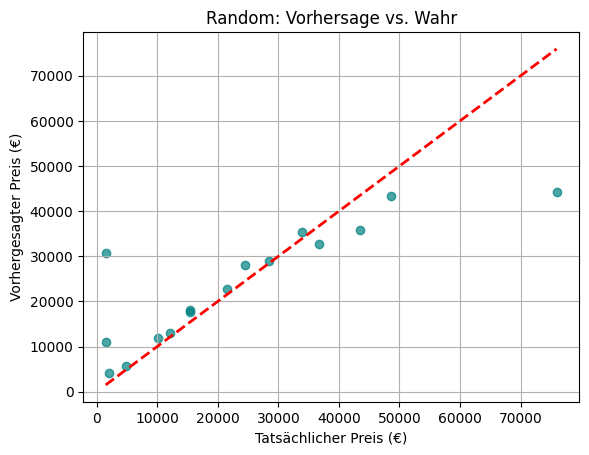

In [ ]:
y_pred_train = model_random.predict(x_train)
y_pred_test = model_random.predict(x_test)


plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Random: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

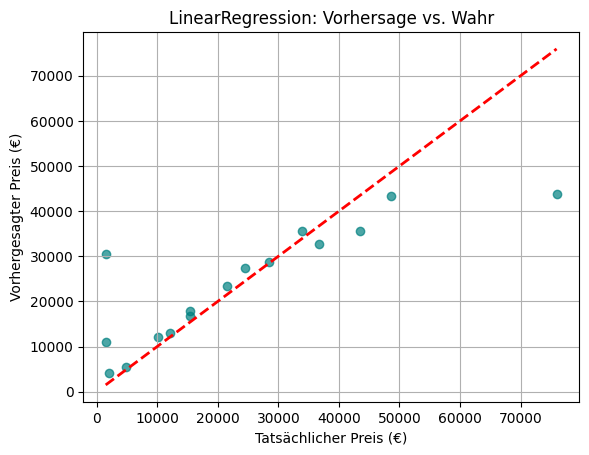

In [ ]:
y_pred_train = model_LR.predict(x_train)
y_pred_test = model_LR.predict(x_test)


plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("LinearRegression: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

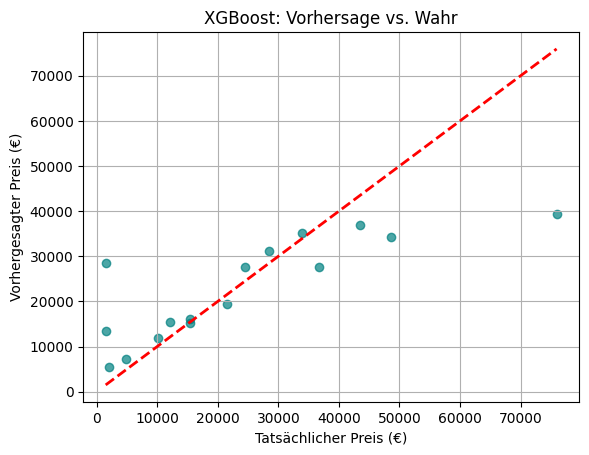

In [ ]:
# Ensure the pipeline is fitted before predicting
# (fits will train StandardScaler and the XGBRegressor)
model_xGboox.fit(x_train, y_train)

y_pred_train = model_xGboox.predict(x_train)
y_pred_test = model_xGboox.predict(x_test)

plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("XGBoost: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'distplot'

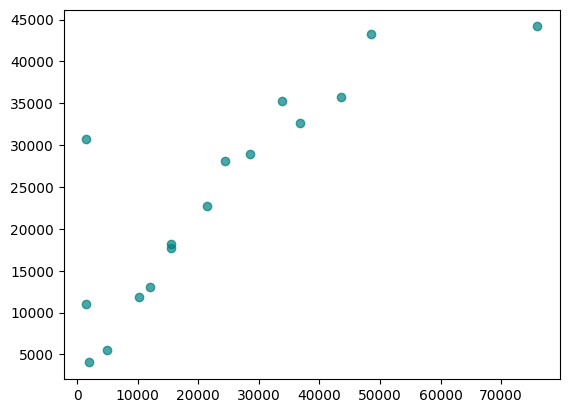

In [ ]:
y_pred_train = model_random.predict(x_train)
y_pred_test = model_random.predict(x_test)


plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
#plt.distplot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Random: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()